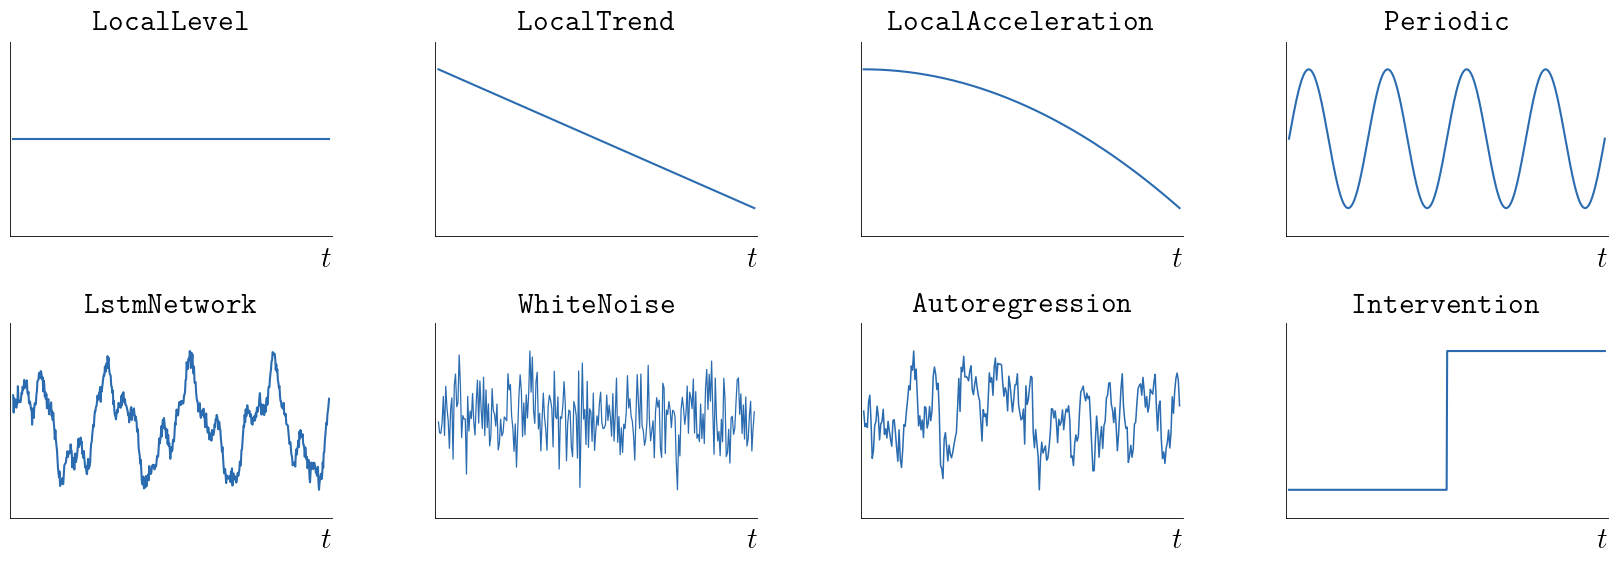

In [56]:
"""Schematic figure of the canari components: one titled panel per component."""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

FONT_SIZE = 22          # 22 for slides; ~10 when the .pgf goes into the paper

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "lines.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pgf.texsystem": "pdflatex",
    "pgf.rcfonts": False,
    "pgf.preamble": r"\usepackage{lmodern}",
})

LINE_COLOR = "#2b6cb0"
TITLE_COLOR = "black"

rng = np.random.default_rng(3)
t = np.linspace(0.0, 1.0, 600)
t_res = np.linspace(0.0, 1.0, 260)      # coarser grid for the residual panels


def ar1(n, phi=0.85, sigma=1.0, rng=rng):
    """Sample an AR(1) process x_t = phi * x_{t-1} + eps_t."""
    eps = sigma * rng.standard_normal(n)
    x = np.empty(n)
    x[0] = eps[0] / np.sqrt(1.0 - phi**2)          # stationary initial state
    for k in range(1, n):
        x[k] = phi * x[k - 1] + eps[k]
    return x


level = np.zeros_like(t)
trend = -0.9 * t
acceleration = -1.7 * t**2
periodic = np.sin(2 * np.pi * 4 * t)
lstm = (np.sin(2 * np.pi * 4 * t)
        + 0.45 * np.sin(2 * np.pi * 11 * t + 0.7)
        + 0.25 * np.sin(2 * np.pi * 23 * t + 1.9)
        + 0.10 * rng.standard_normal(t.size))
white_noise = 0.35 * rng.standard_normal(t_res.size)
autoregression = ar1(t_res.size, phi=0.85, sigma=0.35)
intervention = np.where(t < 0.5, 0.0, 0.85)


def panel(ax, y, label, title, ylim=None, x=None, lw=1.5):
    ax.plot(t if x is None else x, y, color=LINE_COLOR, lw=lw,
            solid_joinstyle="round", clip_on=False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.margins(x=0.01, y=0.20)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_title(title, color=TITLE_COLOR, pad=8)
    ax.text(-0.05, 1.0, label, transform=ax.transAxes, ha="right", va="center")
    ax.text(1.0, -0.05, r"$t$", transform=ax.transAxes, ha="right", va="top")


fig = plt.figure(figsize=(17, 5.6))
gs = GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.32,
              left=0.05, right=0.99, top=0.92, bottom=0.07)

# panel(fig.add_subplot(gs[0, 0]), level, r"$x_{\mathrm{LL}}$", "Local level", ylim=(-1, 1))
# panel(fig.add_subplot(gs[0, 1]), trend, r"$x_{\mathrm{LT}}$", "Local trend")
# panel(fig.add_subplot(gs[0, 2]), acceleration, r"$x_{\mathrm{LA}}$", "Local acceleration")
# panel(fig.add_subplot(gs[0, 3]), periodic, r"$x_{\mathrm{S}}$", "Periodic")
# panel(fig.add_subplot(gs[1, 0]), lstm, r"$x_{\mathrm{LSTM}}$", "LSTM")
# panel(fig.add_subplot(gs[1, 1]), white_noise, r"$x_{\mathrm{WN}}$", "White noise", x=t_res, lw=0.9)
# panel(fig.add_subplot(gs[1, 2]), autoregression, r"$x_{\mathrm{AR}}$", "Autoregression", x=t_res, lw=1.1)



panel(fig.add_subplot(gs[0, 0]), level,"", r"$\mathtt{LocalLevel}$", ylim=(-1, 1))
panel(fig.add_subplot(gs[0, 1]), trend,"",r"$\mathtt{LocalTrend}$")
panel(fig.add_subplot(gs[0, 2]), acceleration,"",r"$\mathtt{LocalAcceleration}$")
panel(fig.add_subplot(gs[0, 3]), periodic, "",r"$\mathtt{Periodic}$")
panel(fig.add_subplot(gs[1, 0]), lstm, "", r"$\mathtt{LstmNetwork}$")
panel(fig.add_subplot(gs[1, 1]), white_noise, "", r"$\mathtt{WhiteNoise}$", x=t_res, lw=0.9)
panel(fig.add_subplot(gs[1, 2]), autoregression, "", r"$\mathtt{Autoregression}$", x=t_res, lw=1.1)
panel(fig.add_subplot(gs[1, 3]), intervention, "", r"$\mathtt{Intervention}$")


fig.savefig("components.pdf", bbox_inches="tight")
fig.savefig("components.pgf", bbox_inches="tight")

In [ ]:

panel(fig.add_subplot(gs[0, 0]), level,"", r"$\mathtt{LocalLevel}$", ylim=(-1, 1))
panel(fig.add_subplot(gs[1, 0]), trend,"",r"$\mathtt{LocalTrend}$")
panel(fig.add_subplot(gs[2, 0]), acceleration,"",r"$\mathtt{LocalAcceleration}$")
panel(fig.add_subplot(gs[0, 1]), periodic, "",r"$\mathtt{Periodic}$")
panel(fig.add_subplot(gs[1, 1]), lstm, "", r"$\mathtt{LstmNetwork}$")
panel(fig.add_subplot(gs[0, 2]), white_noise, "", r"$\mathtt{WhiteNoise}$", x=t_res, lw=0.9)
panel(fig.add_subplot(gs[1, 2]), autoregression, "", r"$\mathtt{Autoregression}$", x=t_res, lw=1.1)

fig.savefig("components.pdf", bbox_inches="tight")
fig.savefig("components.pgf", bbox_inches="tight")